# 03 – Analysis

**Input:** data/processed/meals_clean.csv (17,076 meals, 23 canteens, 13 cities)

**Questions**
1. How do main dish prices for students differ between cities?
2. Are vegan main dishes cheaper than meat main dishes (within the same canteen)?
3. How did main dish prices change between 2024 and 2026?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/meals_clean.csv", parse_dates=["date"])
print(df.shape)
df.dtypes

(17076, 13)


id                           int64
name                           str
category                       str
notes                          str
canteen_id                   int64
canteen_name                   str
city                           str
date                datetime64[us]
prices.students            float64
prices.employees           float64
prices.others              float64
meal_type                      str
meal_role                      str
dtype: object

In [2]:
mains = df[df["meal_role"] == "main"].copy()
print("Main dishes:", len(mains))

Main dishes: 9602


In [3]:
buffet_like = mains["name"].str.lower().str.contains("zur wahl")
mains[buffet_like].groupby("canteen_name")["prices.students"].agg(["count", "median"])

,count,median
canteen_name,,
"Chemnitz, Straße der Nationen, Mensa",1,4.6


## Q1 – How do main dish prices differ between cities?
I use the **median** student price, because a few expensive specials would distort the mean.

In [4]:
city_prices = (
    mains.groupby("city")["prices.students"]
    .agg(["count", "median", "mean", "min", "max"])
    .round(2)
    .sort_values("median")
)
city_prices

,count,median,mean,min,max
city,,,,,
Leipzig,1317,2.10,2.60,1.70,4.50
Heidelberg,169,2.90,3.10,2.90,5.50
Passau,425,3.10,3.32,2.00,6.20
Köln,724,3.30,3.54,2.55,7.75
Straubing,254,3.30,3.51,2.00,6.50
Nürnberg,725,3.49,3.56,2.43,5.99
Dresden,925,3.60,3.53,2.18,5.10
Saarbrücken / Saarland,732,3.70,4.17,2.30,7.90
Regensburg,725,3.80,3.56,2.00,6.50


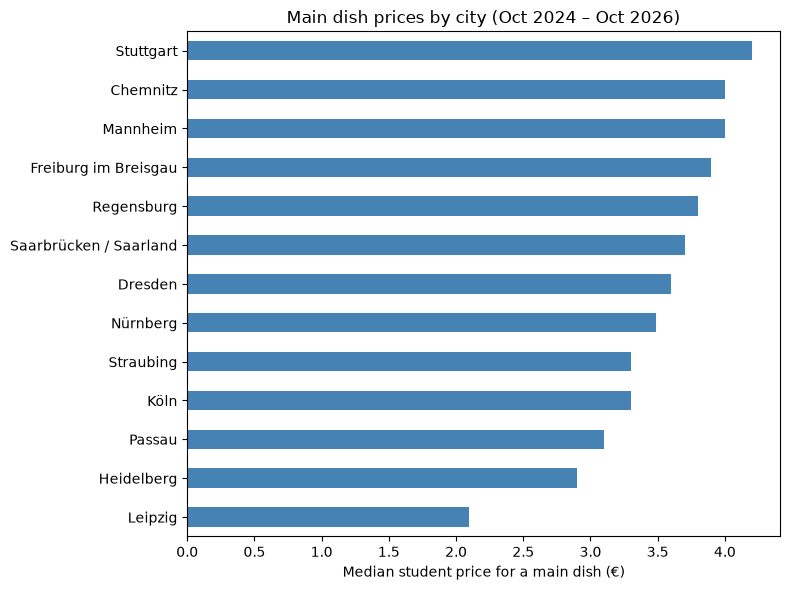

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

city_prices["median"].plot(kind="barh", ax=ax, color="steelblue")

ax.set_xlabel("Median student price for a main dish (€)")
ax.set_ylabel("")
ax.set_title("Main dish prices by city (Oct 2024 – Oct 2026)")

plt.tight_layout()
plt.savefig("../reports/q1_median_price_by_city.png", dpi=150)
plt.show()

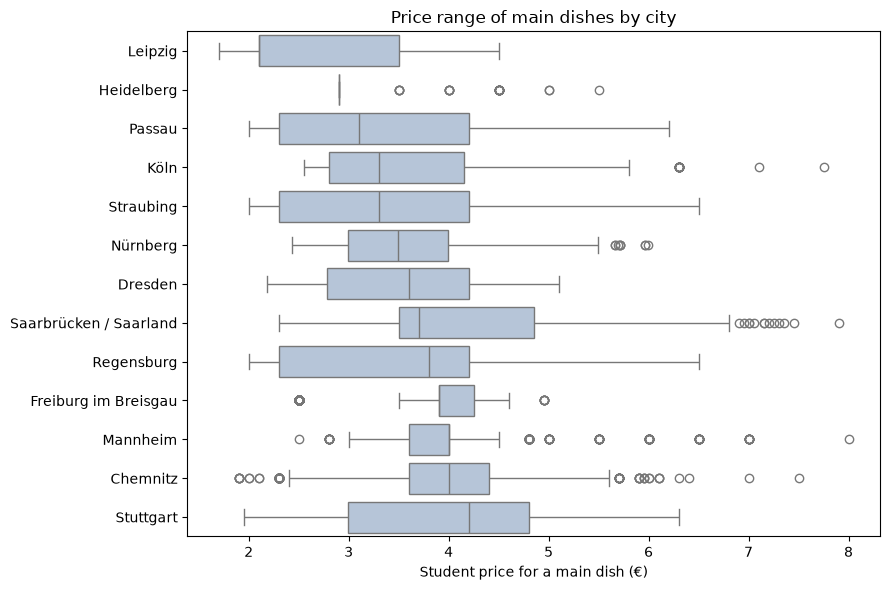

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(data=mains, x="prices.students", y="city",
            order=city_prices.index, color="lightsteelblue", ax=ax)

ax.set_xlabel("Student price for a main dish (€)")
ax.set_ylabel("")
ax.set_title("Price range of main dishes by city")

plt.tight_layout()
plt.savefig("../reports/q1_price_range_by_city.png", dpi=150)
plt.show()

In [7]:
  mains[(mains["city"] == "Freiburg im Breisgau") & (mains["prices.students"] < 2)][["name", "prices.students"]].head(10)

,name,prices.students


### Findings Q1
- **Cheapest:** Leipzig, median €2.10 per main dish. Leipzig offers cheap dishes every day
  (e.g. Germknödel, Kartoffelpuffer for €1.70), so its mean (€2.60) is clearly above its median.
- **Most expensive:** Stuttgart (€4.20), followed by Mannheim and Chemnitz (€4.00).
  Stuttgart is represented by only one small art-academy cafeteria (211 mains), so it's not representative of the whole city.
- **Difference:** about €1.90 per main dish between Leipzig and Mannheim/Chemnitz.
  For a student eating at the Mensa 20 days a month, that's roughly **€38 per month**.
- **Region is not the explanation:** Leipzig and Dresden (Saxony) are among the cheaper cities,
  but Chemnitz (also Saxony) is among the most expensive. Each Studierendenwerk sets its own prices.
- **Caveats:** each city is represented by only 1–2 canteens. Heidelberg prices by component
  (many mains at exactly €2.90), so its prices may be lower than a full plate elsewhere.